# Credit Card Risk Modeling

Rene Sangacha

In [1]:
############################################# Credit Card Risk Modeling ###################################################

# Proyecto del primer módulo del curso de Credit Scoring

############################################################################################################################

#____________________ Librerias ----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, recall_score, \
							precision_score, precision_recall_curve, roc_curve, auc
from sklearn.calibration import calibration_curve

import os
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

import scorecardpy as sc
from scorecardpy import woebin, woebin_ply, scorecard


In [2]:
#____________________ Direcciones ----

dir_p=os.getcwd()
dir_p=dir_p.replace('\\scripts','')

dir_r=dir_p+'\\results'
dir_s=dir_p+'\\scripts'
dir_b=dir_p+'\\data'

In [3]:
#____________________ Lectura de datos ----

train=pd.read_csv(dir_b+r'/train.csv',engine='c')
test=pd.read_csv(dir_b+r'/test.csv',engine='c')

In [4]:
#____________________ EDA ----

#~~~~ Variables ----

print(train.columns)
print('\n\t\ttrain\n')
print(test.columns)
print(set(train.columns)-set(test.columns))

#~~~~ Tipos de datos ----

print(train.dtypes)
print('\n\t\ttrain\n')
print(test.dtypes)

#~~~~ NA's ----

print(train.info())
print('\n\t\ttrain\n')
print(test.info())

print(train.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100)
print('\n\t\tTest\n')
print(test.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100)

# Variables con NA's: employment_years, savings_balance,  credit_utilization,  credit_history_length,  income

Index(['customer_id', 'age', 'income', 'employment_years',
       'credit_history_length', 'num_open_accounts', 'num_credit_inquiries',
       'loan_amount', 'credit_utilization', 'savings_balance',
       'debt_to_income', 'savings_to_loan', 'default'],
      dtype='object')

		train

Index(['customer_id', 'age', 'income', 'employment_years',
       'credit_history_length', 'num_open_accounts', 'num_credit_inquiries',
       'loan_amount', 'credit_utilization', 'savings_balance',
       'debt_to_income', 'savings_to_loan'],
      dtype='object')
{'default'}
customer_id                int64
age                        int64
income                   float64
employment_years         float64
credit_history_length    float64
num_open_accounts          int64
num_credit_inquiries       int64
loan_amount              float64
credit_utilization       float64
savings_balance          float64
debt_to_income           float64
savings_to_loan          float64
default                    int64
dtype:

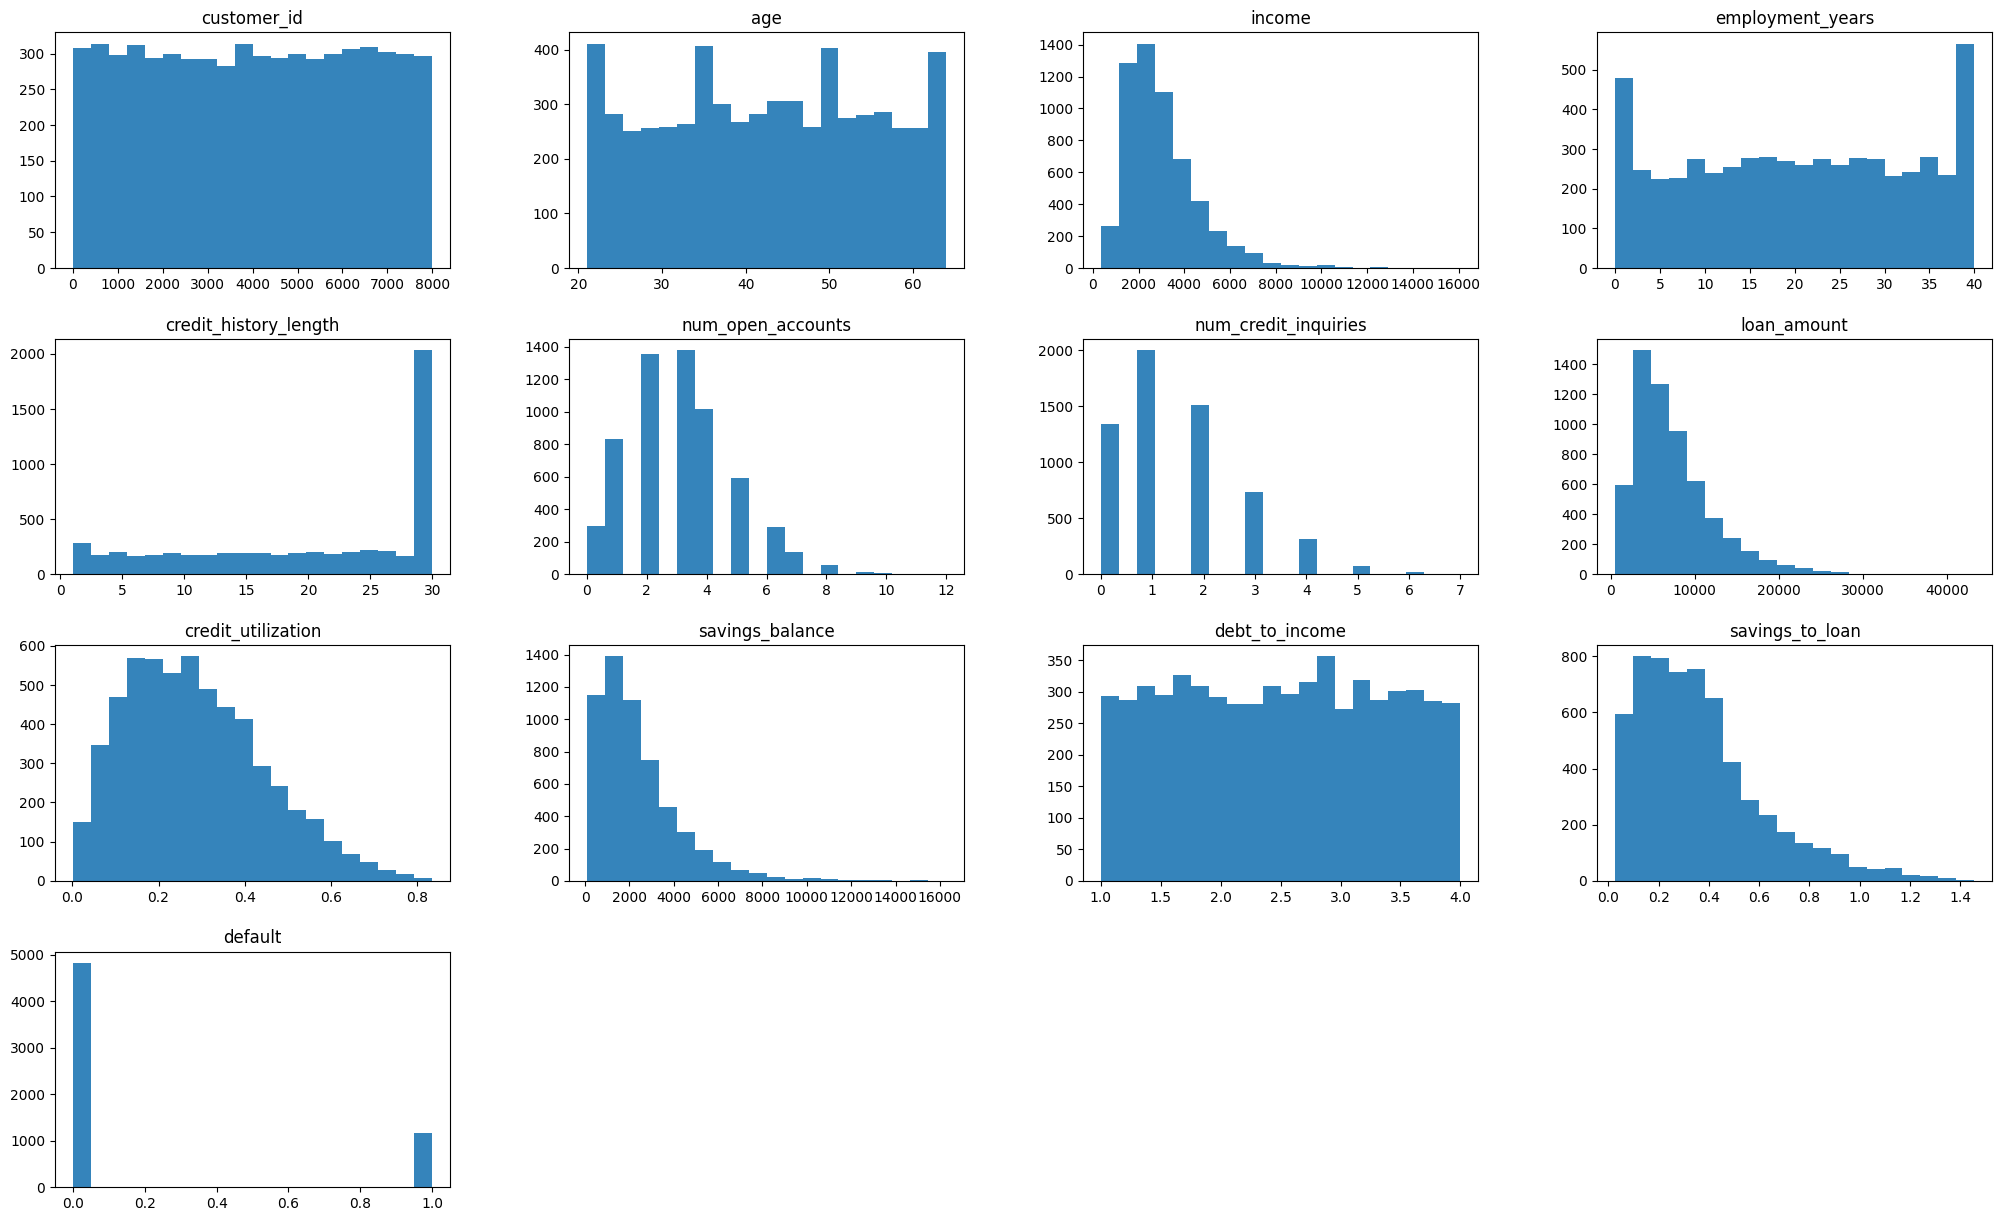

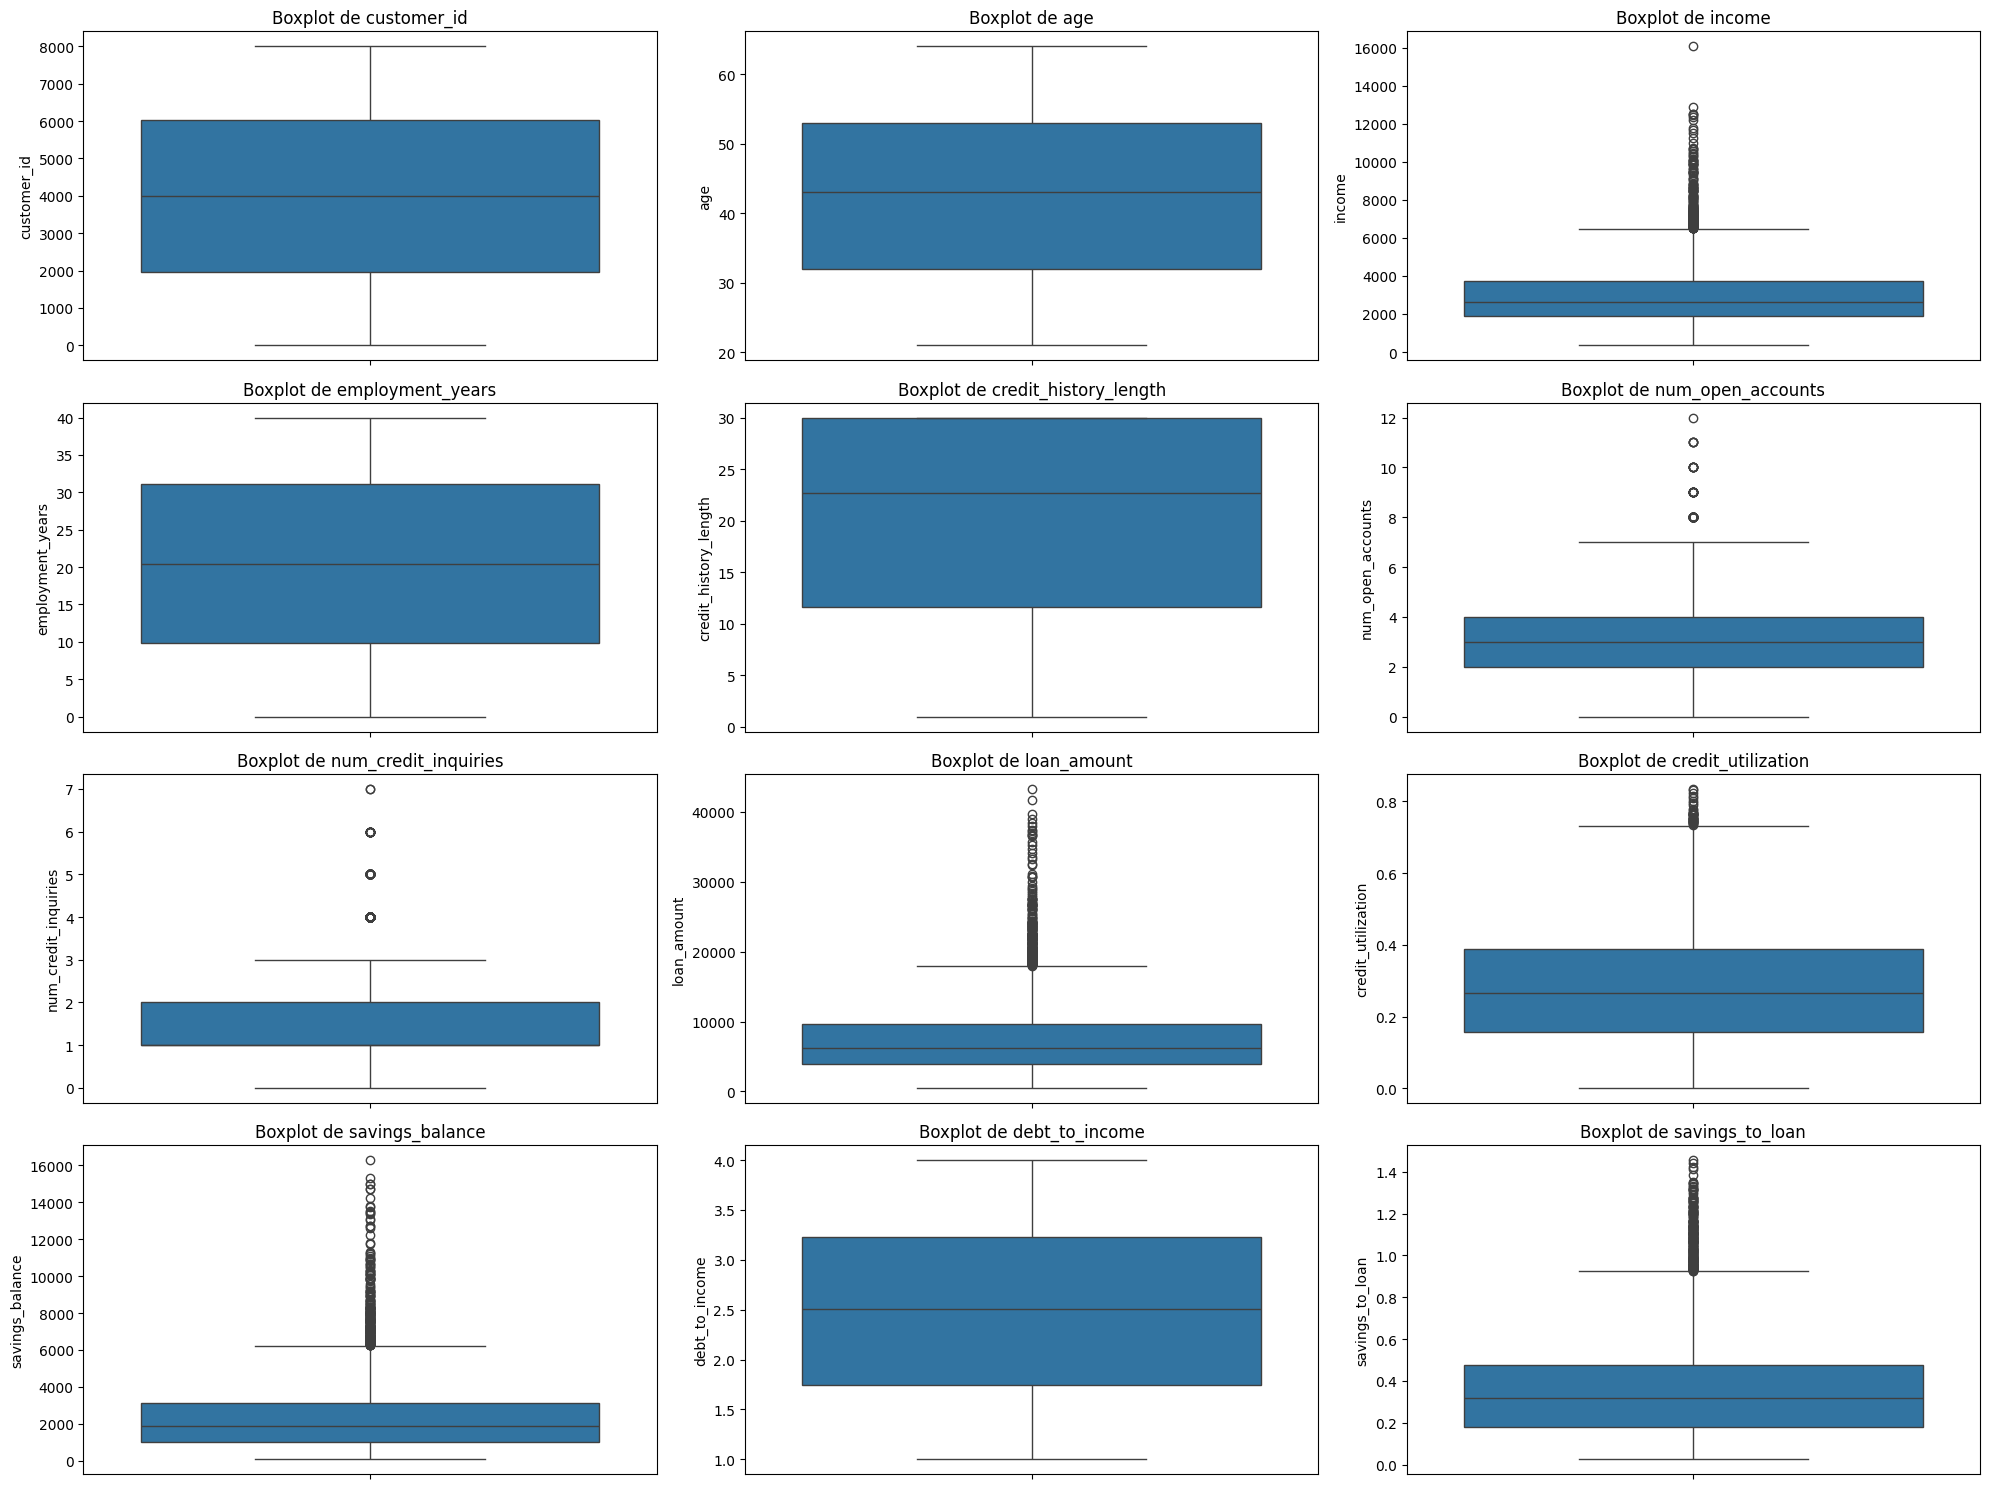

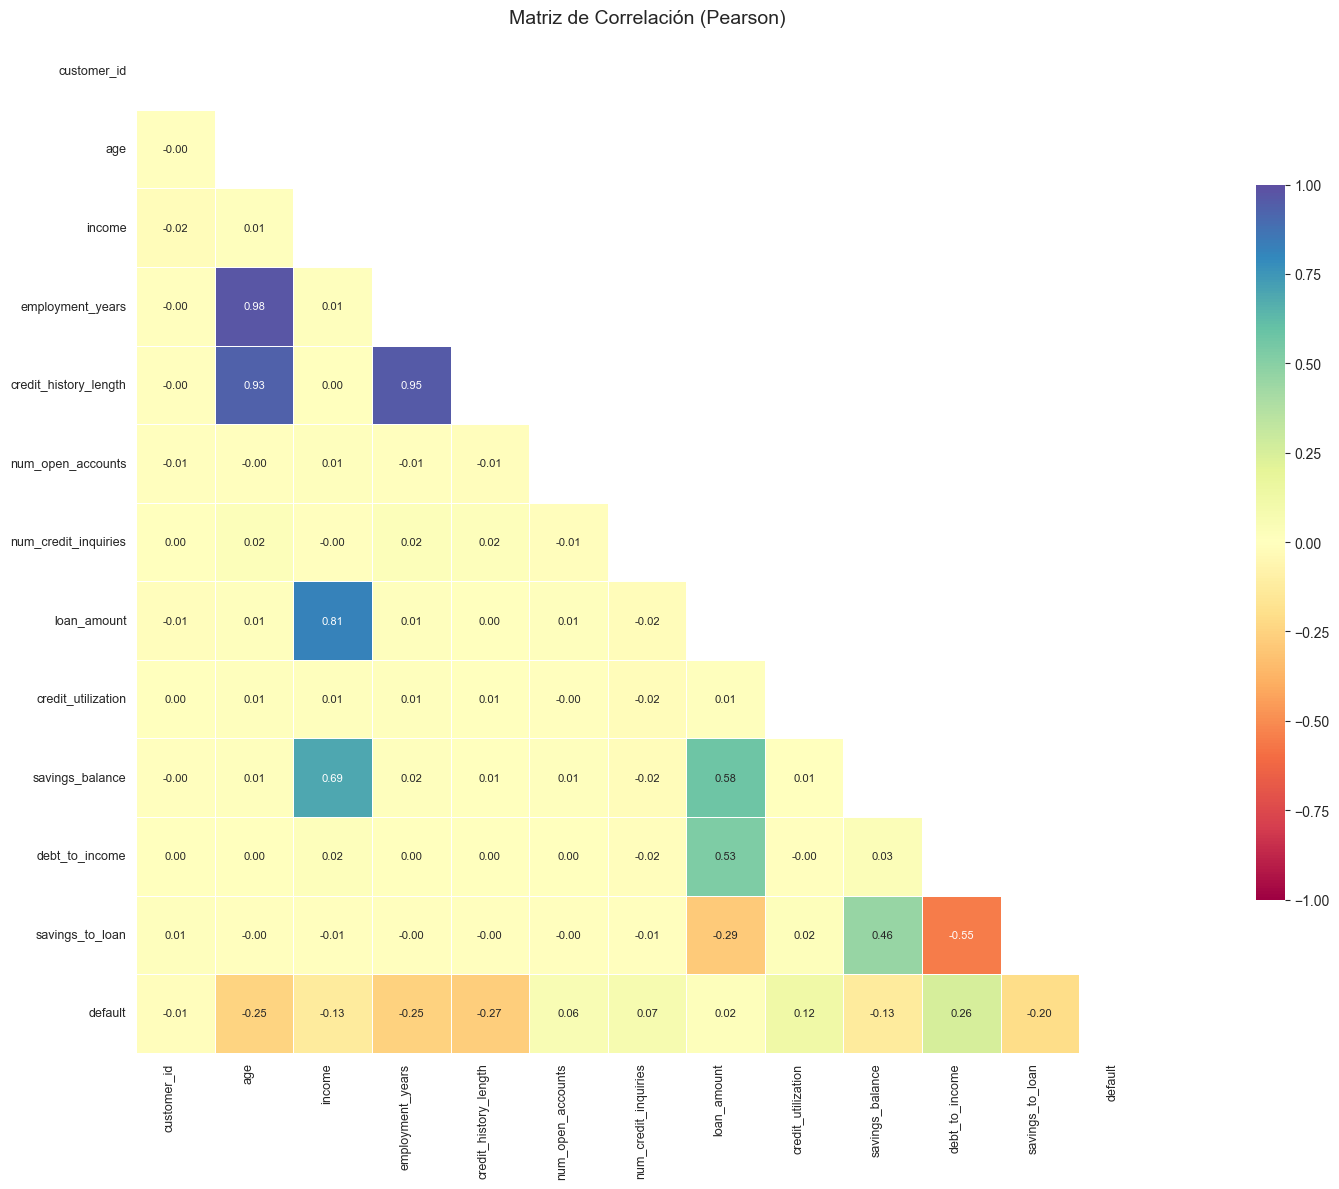

In [5]:
#~~~~ Estadística descriptiva ----

train.head()
train.describe()

# Histogramas
train.hist(bins=20, figsize=(25,15), alpha=0.9, grid=False)

# Diagramas de caja
v_num = train.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))
for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=train, y=col, ax=ax)
    ax.set_title(f'Boxplot de {col}')
    ax.grid(False)
plt.tight_layout()
plt.show()

# Correlaciones
def plot_corr_matrix(
    corr,
    title="Matriz de Correlación",
    figsize=(12, 8),
    annot=True,
    cmap="Spectral",
    mask_upper=True
):
    sns.set_style("white")
    
    # Máscara triangular
    mask = None
    if mask_upper:
        mask = np.triu(np.ones_like(corr, dtype=bool))
    
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmin=-1, vmax=1,
        square=True,
        annot=annot,
        fmt=".2f",
        annot_kws={"size": 8},
        linewidths=0.5,
        cbar_kws={"shrink": 0.7, "aspect": 25},
        linecolor='white'
    )

    plt.xticks(rotation=90, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.title(title, fontsize=14)

    plt.tight_layout()
    plt.show()
    
corr = train[v_num].corr()
plot_corr_matrix(
    corr,
    title="Matriz de Correlación (Pearson)",
    figsize=(20, 12)
)


In [6]:
#____________________ Validaciones ----

# Validaciones de data
train.query('employment_years.notna() & employment_years>age')
test.query('employment_years.notna() & employment_years>age')

train.query('credit_history_length.notna() & credit_history_length>age')
test.query('credit_history_length.notna() & credit_history_length>age')


,customer_id,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan


In [7]:
#____________________ Imputación de variables ----

# No existen clientes con historial crediticio igual a 0.
# Se asume que los NA corresponden a clientes sin historial y se imputan con 0.
train.query('credit_history_length == 0')
train.credit_history_length.fillna(0, inplace=True)
test.credit_history_length.fillna(0, inplace=True)

# No se observan clientes con utilización de crédito igual a 0.
# Los NA se imputan con 0, asumiendo que el cliente no utiliza o no dispone de crédito.
train.query('credit_utilization == 0')
train.credit_utilization.fillna(0, inplace=True)
test.credit_utilization.fillna(0, inplace=True)

# No existen clientes con balance de ahorros igual a 0.
# Los NA se imputan con 0, asumiendo que el cliente no dispone de ahorros.
train.query('savings_balance == 0')
train.savings_balance.fillna(0, inplace=True)
test.savings_balance.fillna(0, inplace=True)

# No se observan clientes con ingreso igual a 0
train.query('income == 0')

# Sí existen clientes con 0 años de empleo
train.query('employment_years == 0')

# Segmentación por edad para analizar los NA de ingresos y años de empleo
train['edad_segmento'] = pd.qcut(train['age'], q=5, duplicates='drop').astype(str)

train.groupby('edad_segmento').agg(
    nas_laboral=('employment_years', lambda x: x.isna().mean()),
    mediana_laboral=('employment_years','median'),
    nas_income=('income', lambda x: x.isna().mean()),
    mediana_income=('income','median'),
)

# Comparación de tasas de default de clientes con y sin información
train.query('income.isna()').default.mean()
train.query('income.notna()').default.mean()

train.query('employment_years.isna()').default.mean()
train.query('employment_years.notna()').default.mean()

# Conclusión:
# Los NA en ingreso y experiencia laboral no se concentran por edad
# ni presentan diferencias relevantes en la tasa de default.

# Tratamiento:
# 1. Imputación por mediana dentro de cada rango de edad (preferible a la media por sesgo positivo).
# 2. NA como categoría independiente en WoE.

train['employment_years_imputado'] = train['employment_years'].fillna(
    train.groupby('edad_segmento')['employment_years'].transform('median')
)

train['income_imputado'] = train['income'].fillna(
    train.groupby('edad_segmento')['income'].transform('median')
)

test['employment_years_imputado'] = test['employment_years'].fillna(
    train.groupby('edad_segmento')['employment_years'].transform('median')
)

test['income_imputado'] = test['income'].fillna(
    train.groupby('edad_segmento')['income'].transform('median')
)

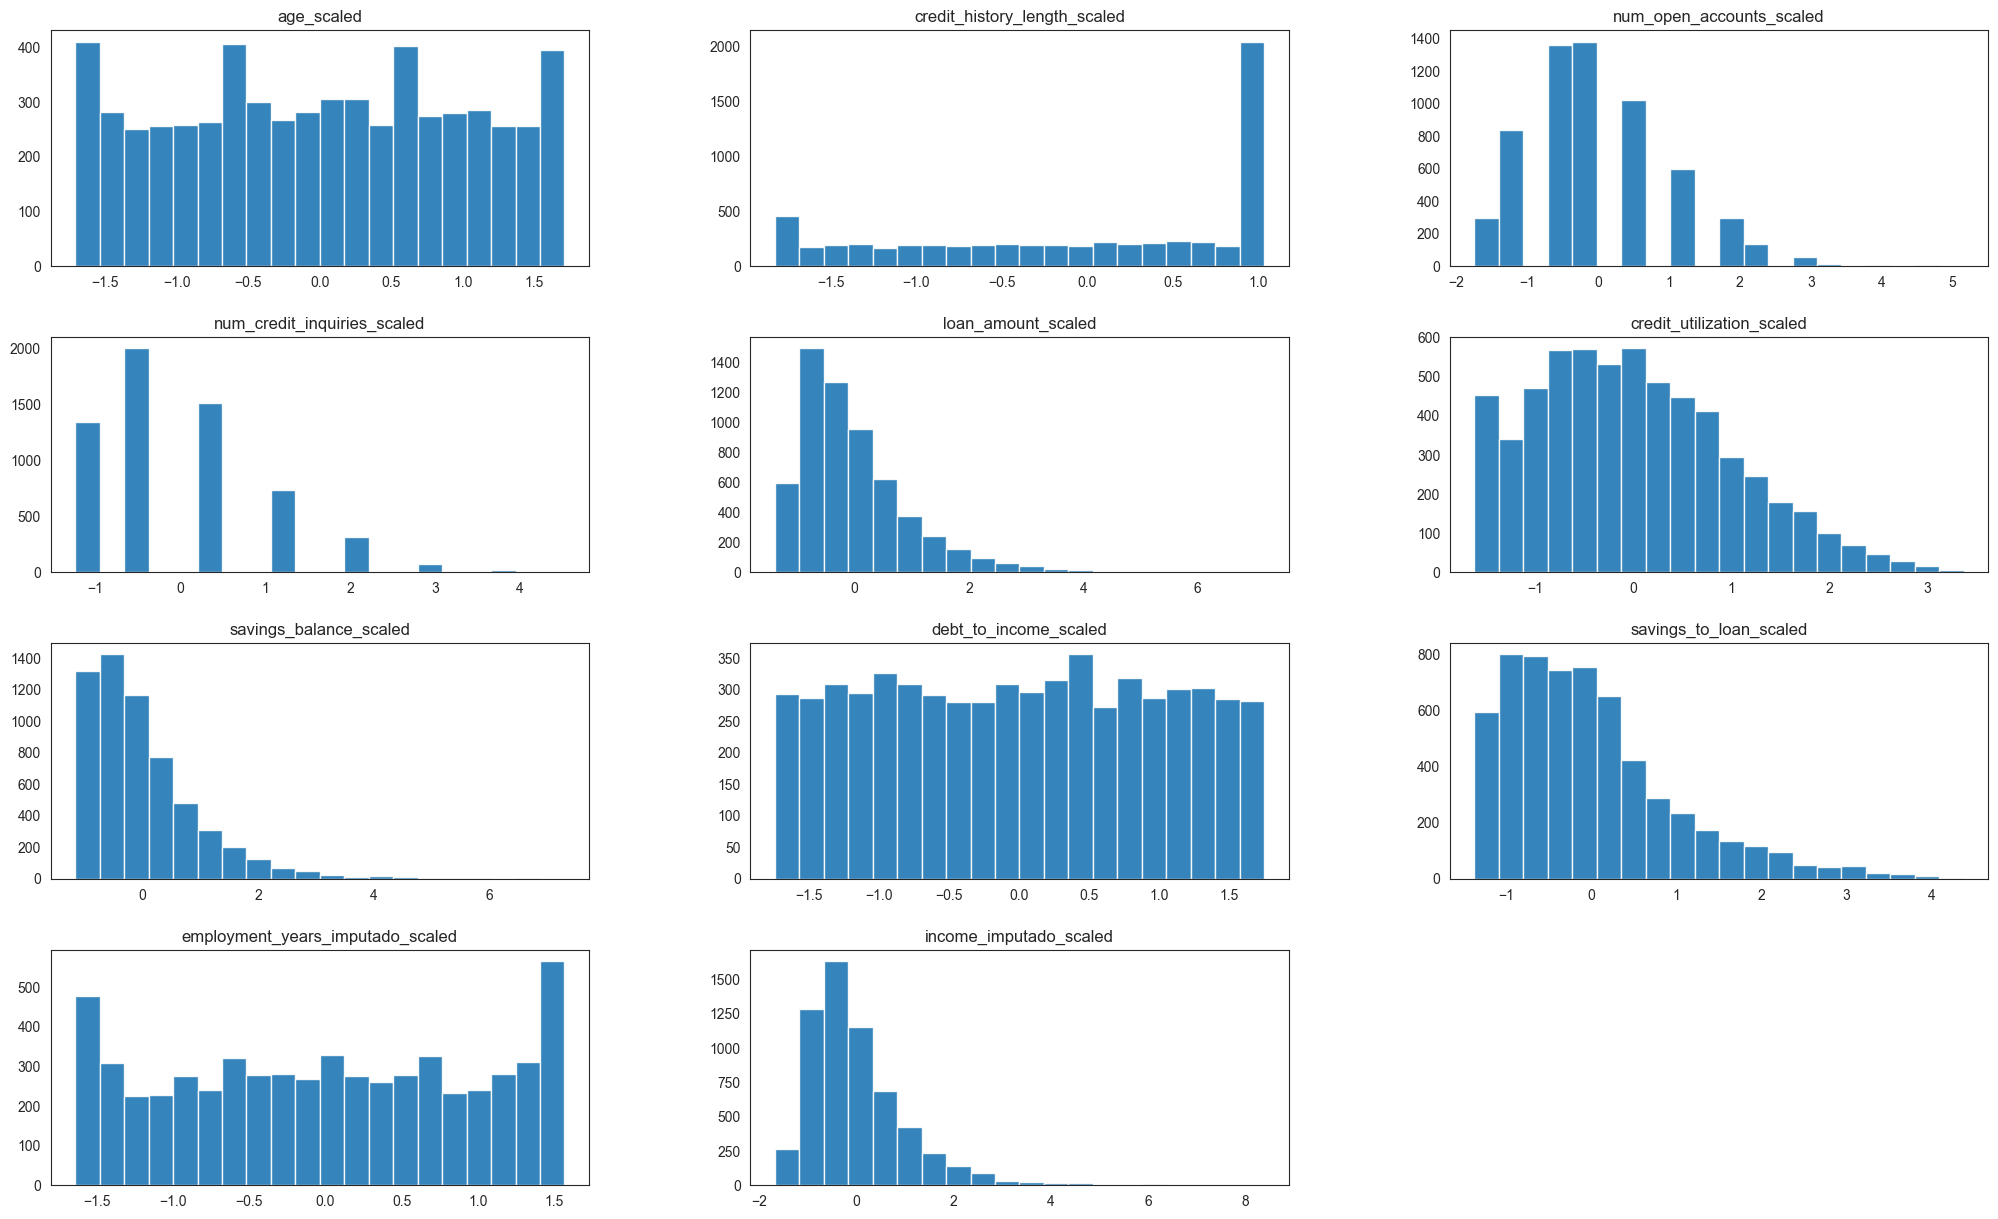

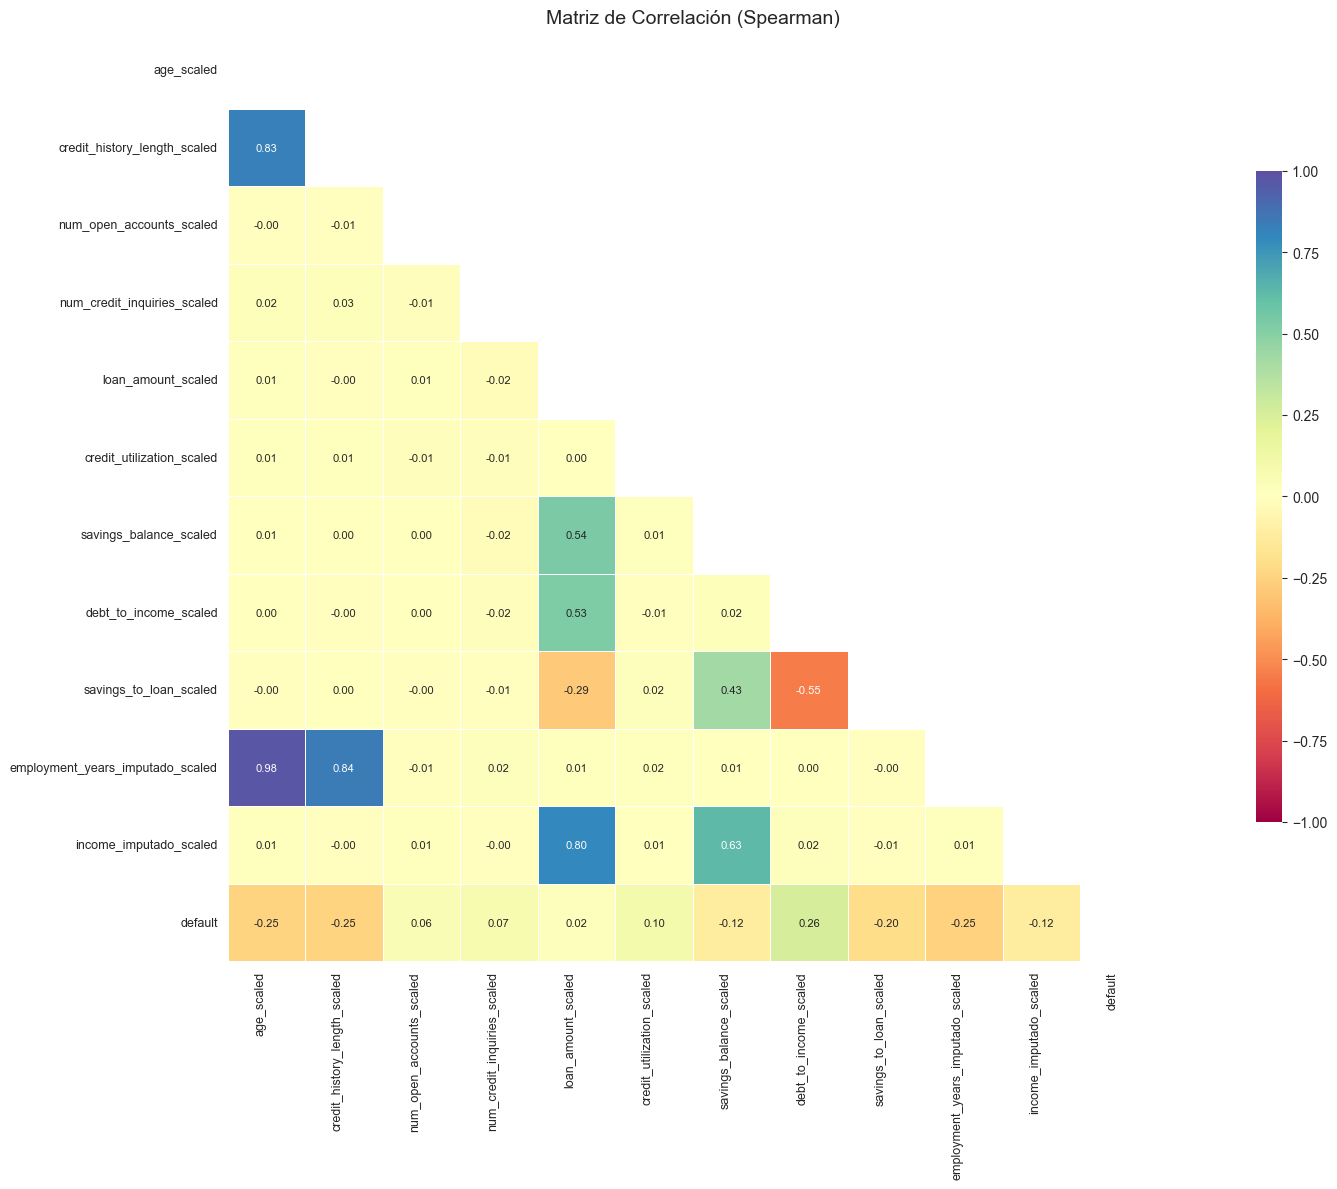

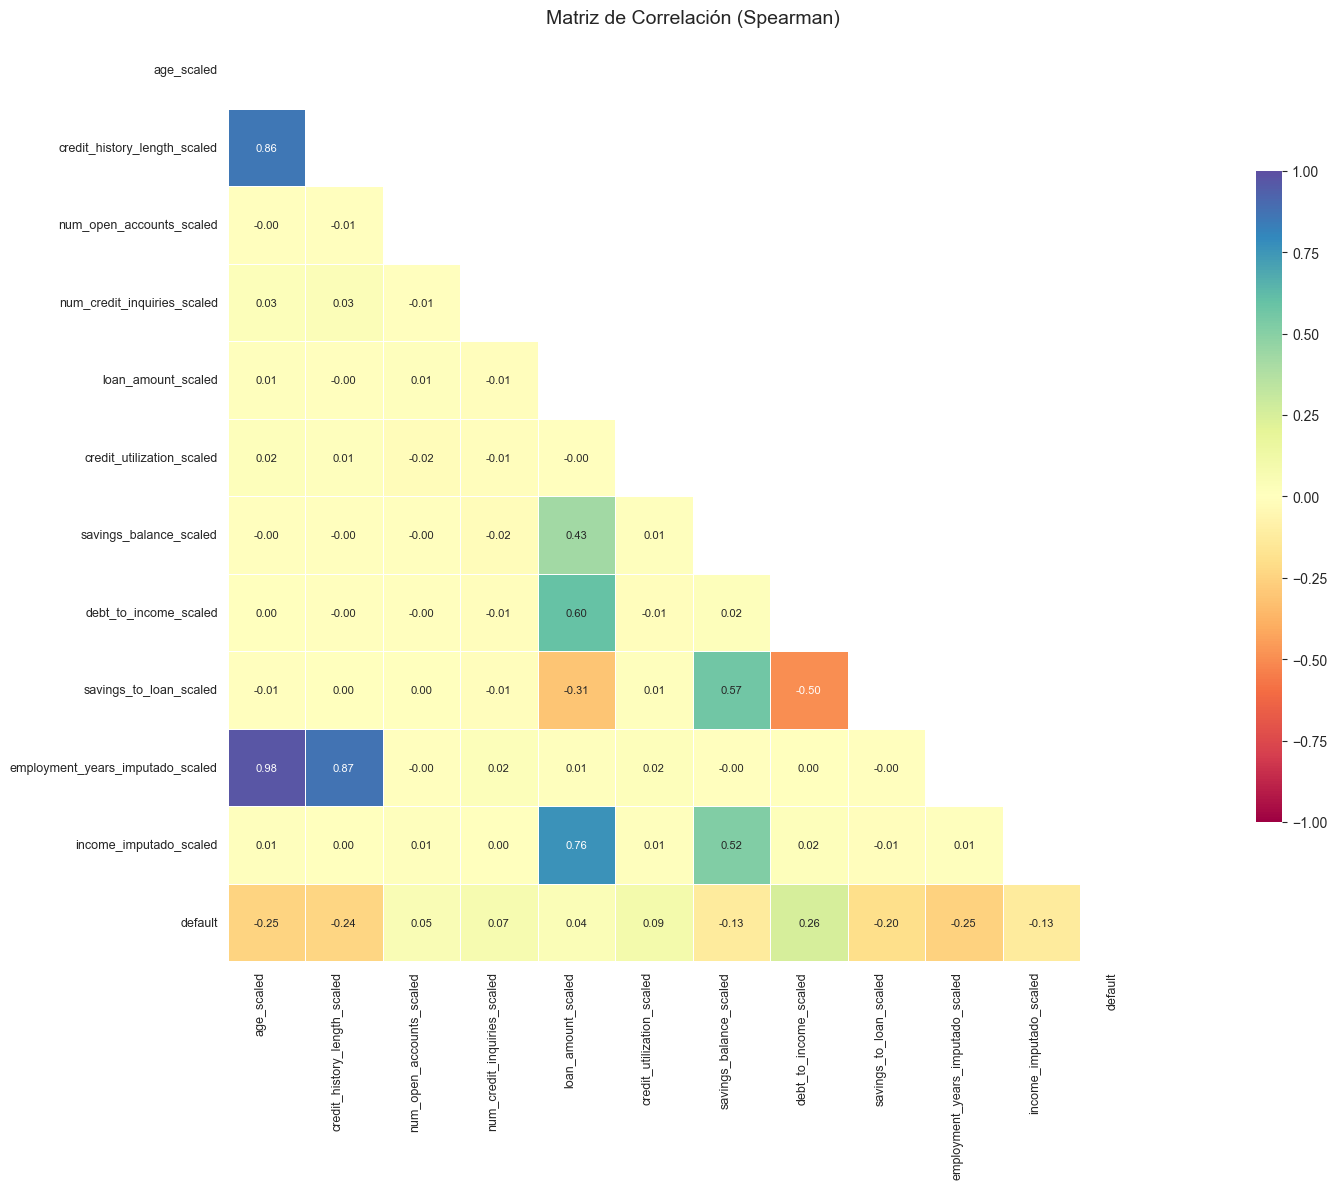

In [8]:
#____________________ Base Line ----

# Se construye un modelo base como punto de referencia para evaluar el desempeño
# de modelos posteriores. En esta etapa se aplica únicamente imputación de valores
# faltantes, evitando mayor ingeniería de variables, con el fin de establecer una
# línea base clara que permita medir de forma objetiva las mejoras en el rendimiento.

# Adicionalmente, se aplica estandarización para evitar que la magnitud de las variables
# influya desproporcionadamente en el modelo.

#~~~~ Estandarizacion ----

vars_sin_nas=[ 'age',
       'credit_history_length', 'num_open_accounts', 'num_credit_inquiries',
       'loan_amount', 'credit_utilization', 'savings_balance',
       'debt_to_income', 'savings_to_loan',
       'employment_years_imputado', 'income_imputado']

scaler_not_nas = StandardScaler()

vars_base_line_scaled=[f"{var}_scaled" for var in vars_sin_nas]

train[vars_base_line_scaled] = scaler_not_nas.fit_transform(train[vars_sin_nas])

# Histogramas
train[vars_base_line_scaled].hist(bins=20, figsize=(25,15), alpha=0.9, grid=False)

# Correlaciones
plot_corr_matrix(
     train[vars_base_line_scaled+['default']].corr(method='pearson'),
    title="Matriz de Correlación (Spearman)",
    figsize=(20, 12)
)

plot_corr_matrix(
     train[vars_base_line_scaled+['default']].corr(method='spearman'),
    title="Matriz de Correlación (Spearman)",
    figsize=(20, 12)
)

# Conclusión:
# Las variables presentan correlaciones débiles con el default (0.10–0.30), sin relaciones individuales fuertes.
# Las variables de tiempo (edad, experiencia laboral e historial crediticio) están altamente correlacionadas entre sí,
# consistente con su naturaleza temporal.

# Para evitar colinealidad, se selecciona el historial crediticio como variable representativa del componente temporal,
# dado que captura la experiencia del cliente en el sistema crediticio.

# Adicionalmente, se excluye la variable loan_amount del modelo base, ya que presenta una correlación muy baja (< 0.05)
# con el default tanto en Spearman como en Pearson.

vars_base_line_scaled=[
 'credit_history_length_scaled',
 'num_open_accounts_scaled',
 'num_credit_inquiries_scaled',
 'credit_utilization_scaled',
 'savings_balance_scaled',
 'debt_to_income_scaled',
 'savings_to_loan_scaled',
 'income_imputado_scaled']


In [9]:
#~~~~ Cross Validation ----
 
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

def run_random_search(model, param_grid, X_train, y_train, cv, scoring='recall', n_iter=10, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    pipeline = Pipeline(steps)
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    
    search.fit(X_train, y_train)
    return search

#~~~~ Ajuste del modelo base: Logit ----

# Se penaliza un error en la clase minoritaria (malos) para mejorar su detección
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

param_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear', 'saga']
}

# Se optimiza por recall para maximizar la detección de clientes malos
search_lr = run_random_search(
    lr, param_lr, train[vars_base_line_scaled], train['default'],
    cv, n_iter=10, scale=False, scoring='recall'
)

print("Best Hyperparameters Found:")
print(search_lr.best_params_)
print(f"Best Recall in CV: {search_lr.best_score_:.4f}")

best_lr = search_lr.best_estimator_
best_lr

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best Hyperparameters Found:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.001}
Best Recall in CV: 0.7898


,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


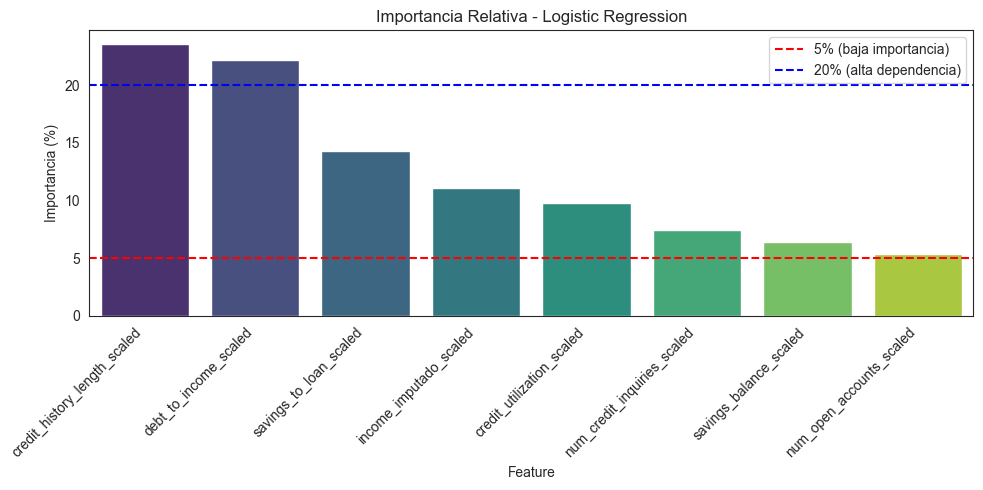

In [10]:
#~~~~ Importancia deVariables: Logit ----

log_reg = best_lr.named_steps['model']

importances = np.abs(log_reg.coef_[0])
features = vars_base_line_scaled

rel_importance = 100* importances / importances.sum()

df_imp = pd.DataFrame({
    'feature': features,
    'importance': importances,
    'rel_importance': rel_importance
}).sort_values('rel_importance', ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_imp,
    x='feature',
    y='rel_importance',
    palette='viridis'
)

plt.axhline(5, color='red', linestyle='--', linewidth=1.5, label='5% (baja importancia)')
plt.axhline(20, color='blue', linestyle='--', linewidth=1.5, label='20% (alta dependencia)')

plt.title("Importancia Relativa - Logistic Regression")
plt.xlabel("Feature")
plt.ylabel("Importancia (%)")

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión:
# Las variables del modelo base presentan una importancia relativamente equilibrada, sin alta concentración en pocas variables.
# A su vez, las variables deuda/ingreso e historial crediticio destacan como los principales drivers del modelo.


0.5191224886345202

📊 Metrics on Train Set (Logistic Regression, Threshold = 0.5191):
Recall: 0.7549
Precision: 0.3719
F1 Score: 0.4983
ROC AUC: 0.7979
Average Precision (PR AUC): 0.4891
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.69      0.79      4825
           1       0.37      0.75      0.50      1175

    accuracy                           0.70      6000
   macro avg       0.65      0.72      0.64      6000
weighted avg       0.81      0.70      0.73      6000



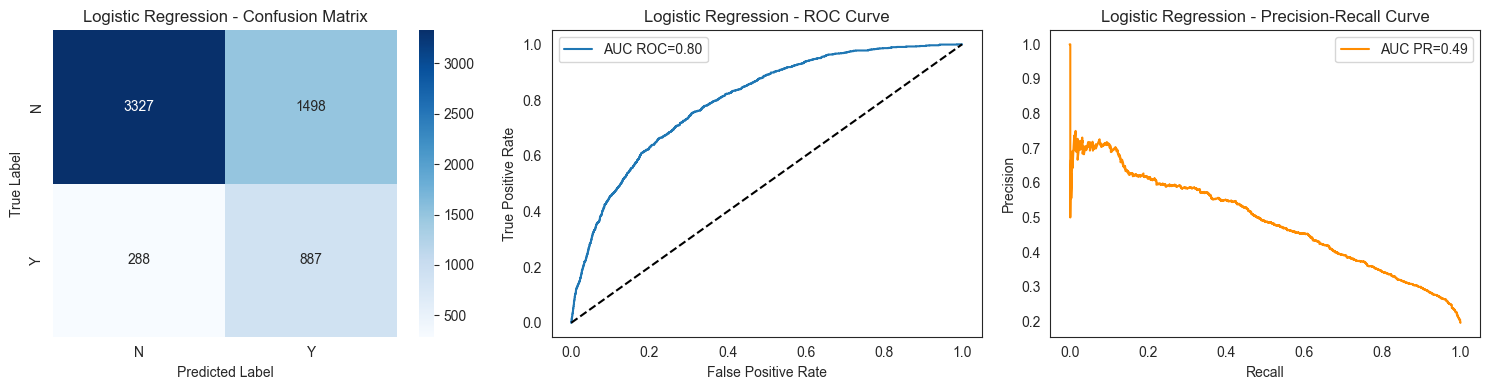

In [11]:
#~~~~ Desempeño del modelo base: Logit ----

def evaluate_model(model, X_test, y_test, name='Model'):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    # criterio de Youden
    j = tpr - fpr
    best_threshold = thresholds[np.argmax(j)]

    print(best_threshold)
    y_pred = (y_proba >= best_threshold).astype(int)
    print(f"\n📊 Metrics on Train Set ({name}, Threshold = {best_threshold:.4f}):")
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("Average Precision (PR AUC):", round(average_precision_score(y_test, y_proba), 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    return y_proba, y_pred

def plot_evaluation(y_test, y_pred, y_proba, model_name='Model'):
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(15, 4))

    # 1. Confusion Matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['N', 'Y'],
                yticklabels=['N', 'Y'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Label') 
    plt.ylabel('True Label')     

    # 2. ROC Curve
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, label=f'AUC ROC={auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()

    # 3. Precision-Recall Curve
    plt.subplot(1, 3, 3)
    plt.plot(recalls, precisions, label=f'AUC PR={pr_auc:.2f}', color='darkorange')
    plt.title(f'{model_name} - Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
y_proba_lr, y_pred_lr = evaluate_model(best_lr, train[vars_base_line_scaled], train['default'], name='Logistic Regression')
plot_evaluation(train['default'], y_pred_lr, y_proba_lr, model_name='Logistic Regression')

# Conclusiones:

# El modelo base presenta un AUC ROC de 0.80, lo que indica que existe un 80% de probabilidad
# de que asigne un score mayor a un cliente malo que a uno bueno.
# En términos relativos, el modelo base es aproximadamente 2.5 veces mejor que un modelo aleatorio
# en la discriminación entre clientes buenos y malos.

train.drop(columns=[f"{var}_scaled" for var in vars_sin_nas], inplace=True)

[INFO] creating woe binning ...
['credit_history_length_scaled', 'savings_to_loan_scaled', 'log_savings_to_loan_scaled', 'employment_years_imputado_scaled', 'log_income_scaled', 'r_loan_income_scaled', 'log_savings_balance_scaled', 'income_imputado_scaled', 'savings_balance_scaled', 'debt_to_income_scaled', 'age_scaled', 'r_income_employment_scaled']
[INFO] converting into woe values ...


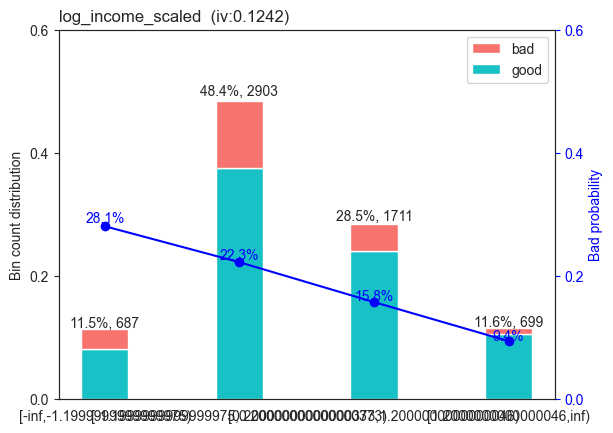

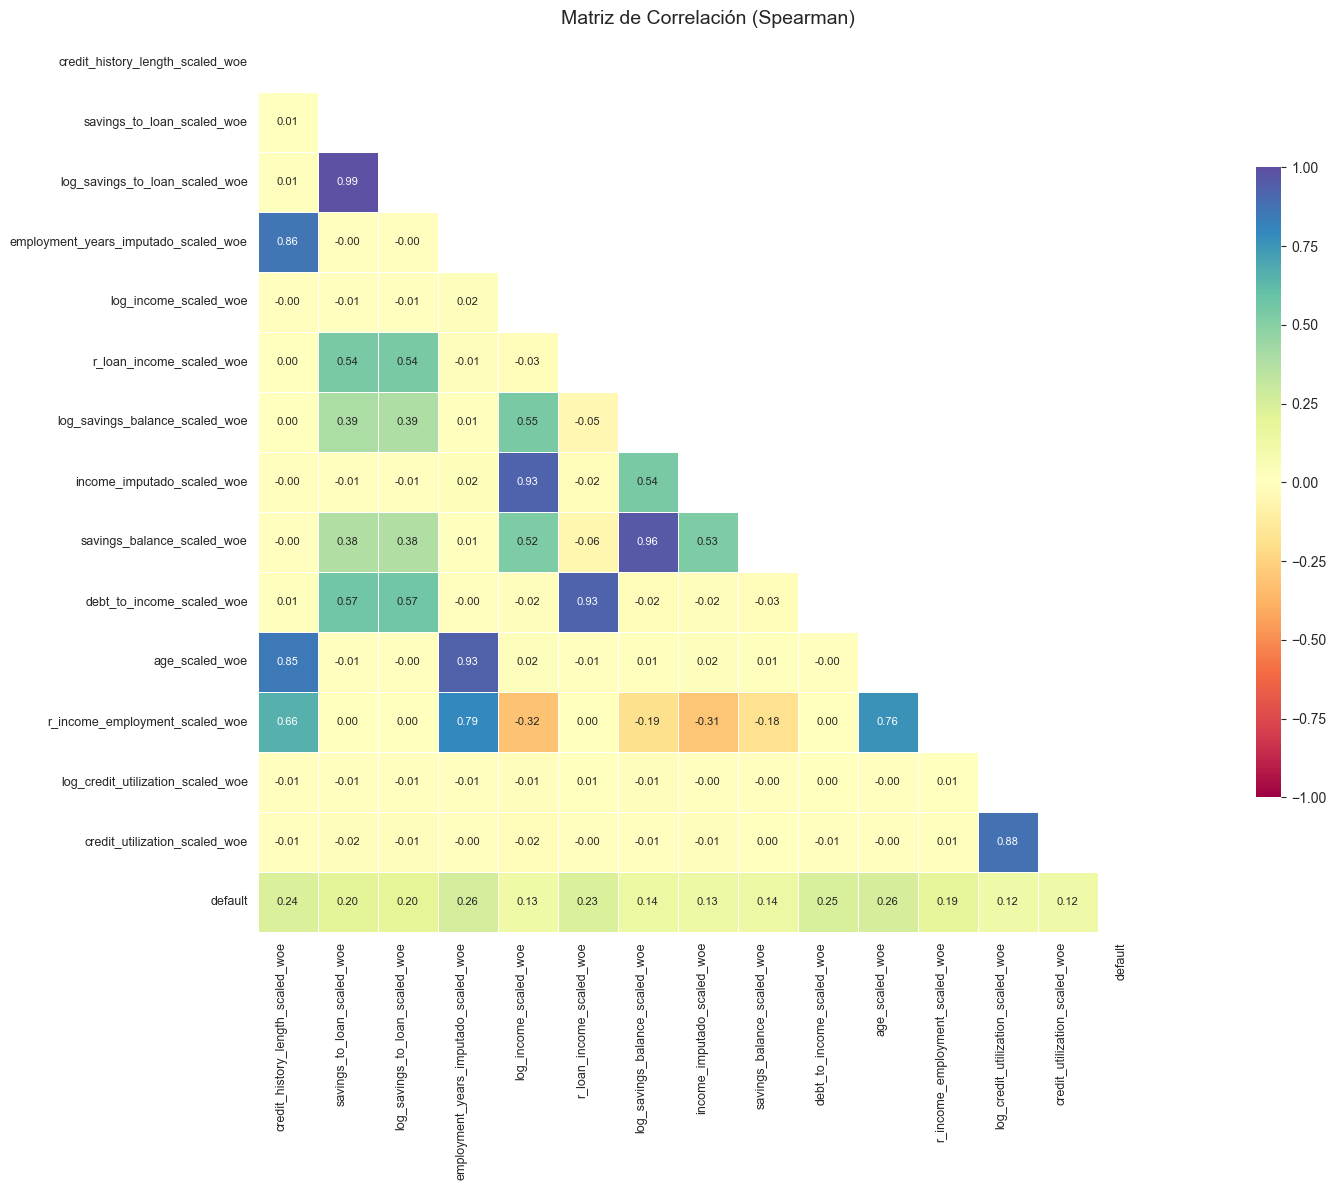

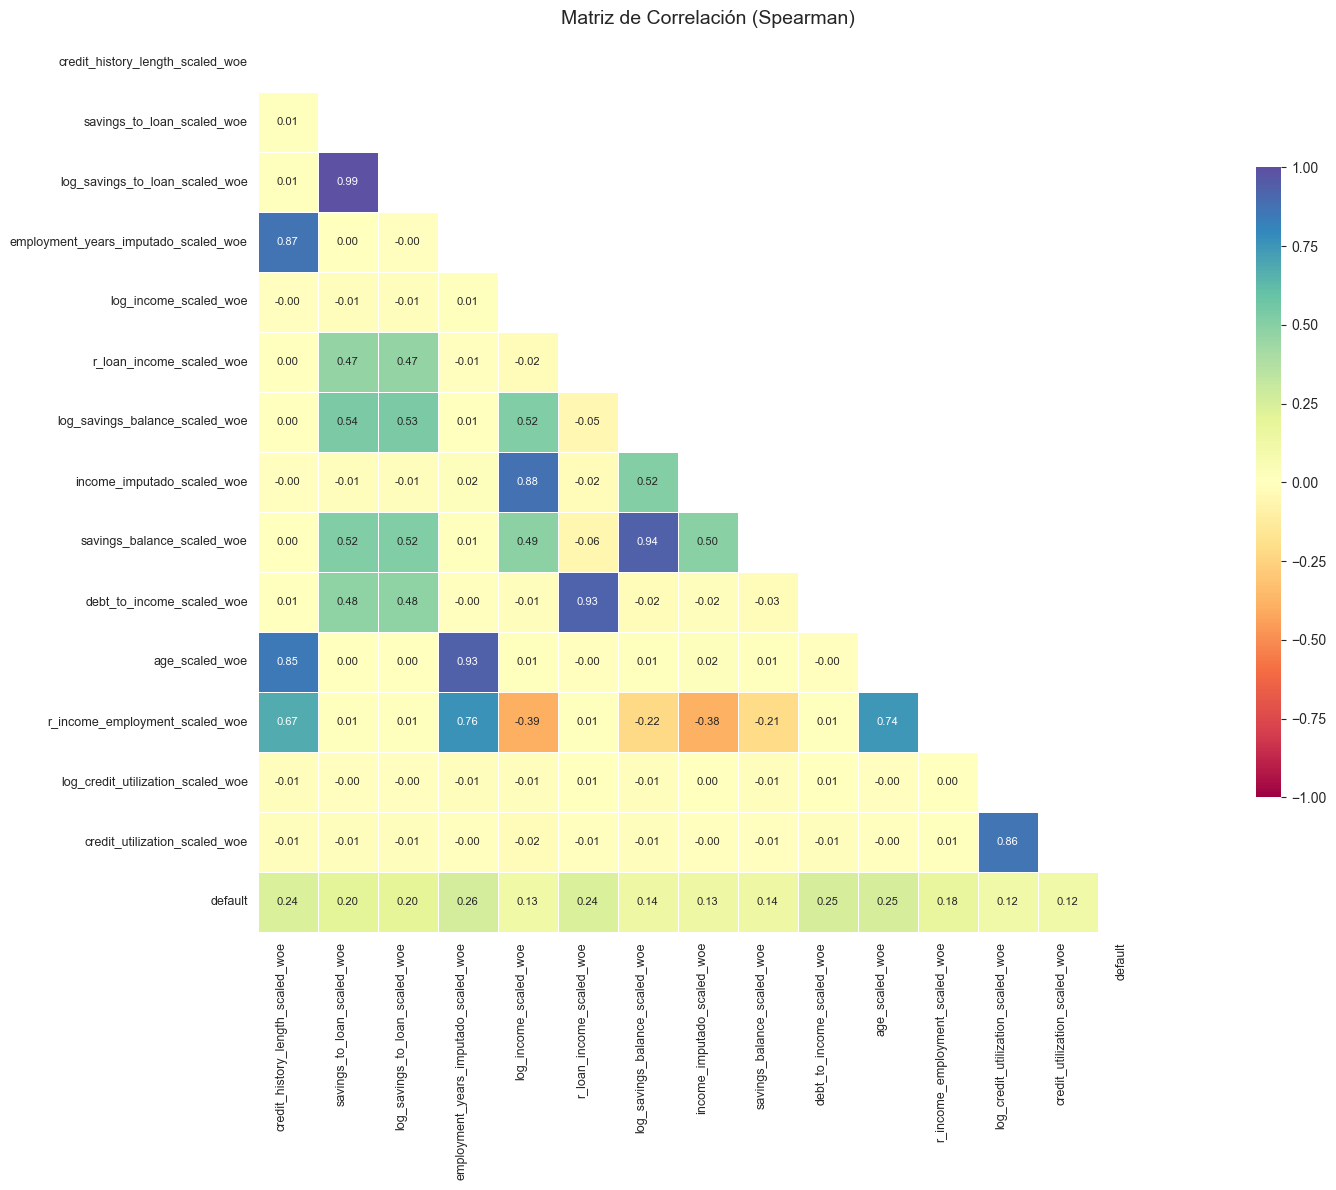

In [12]:
#____________________ Ingenieria de variables ----

#~~~~ Creacion de Variables ----

train = train.assign(
    r_loan_income = train['loan_amount'] / train['income_imputado'].replace(0, np.nan),
    r_income_age = train['income_imputado'] / train['age'].replace(0, np.nan),
    r_savings_age = train['savings_balance'] / train['age'].replace(0, np.nan),
    r_income_employment = train['income_imputado'] / train['employment_years_imputado'].replace(0, np.nan)
)

train['flag_sin_consulta']=(train['num_credit_inquiries']>0).astype(int)
train['log_income']=np.where(train['income_imputado']==0,0, np.log(train['income_imputado']))
train['log_loan_amount']=np.where(train['loan_amount']==0,0, np.log(train['loan_amount']))
train['log_savings_balance']=np.where(train['savings_balance']==0,0, np.log(train['savings_balance']))
train['log_credit_utilization']=np.where(train['credit_utilization']==0,0, np.log(train['credit_utilization']))
train['log_savings_to_loan']=np.where(train['savings_to_loan']==0,0, np.log(train['savings_to_loan']))

nuevas_variables=['r_savings_age','flag_sin_consulta','r_loan_income','r_income_age', 'r_income_employment','log_income','log_loan_amount','log_savings_balance',
                  'log_credit_utilization','log_savings_to_loan']

train.describe()

#~~~~ Estandarizacion ----

scaler_modelo_feature = StandardScaler()

vars_modelo_feature=vars_sin_nas+nuevas_variables

vars_modelo_feature_scaled=[f"{var}_scaled" for var in vars_modelo_feature]

train[vars_modelo_feature_scaled] = scaler_modelo_feature.fit_transform(train[vars_modelo_feature])

#~~~~ WoE ----

bins = sc.woebin(train[vars_modelo_feature_scaled+ ['default']], y='default')

sc.woebin_plot(bins['log_income_scaled'])

iv_list = []
for var, df_bin in bins.items():
    iv = df_bin['total_iv'].iloc[0]   
    iv_list.append((var, iv))

iv_df = pd.DataFrame(iv_list, columns=["variable", "total_iv"])

iv_df.sort_values(by='total_iv', ascending=False)

bins[list(bins.keys())[1]]

good_vars = iv_df.loc[iv_df['total_iv'] > 0.1, 'variable'].tolist()
print(good_vars)

# Se incorporan las variables log_credit_utilization_scaled y credit_utilization_scaled, ya que,
# dentro del conjunto con IV < 0.10, presentan la mayor capacidad predictiva. Además,
# su IV es aproximadamente el doble respecto a la siguiente variable en importancia,
# y que credit_utilization_scaled fue considerada en el modelo baseline.

train=pd.concat([train,sc.woebin_ply(train[good_vars + ['log_credit_utilization_scaled','credit_utilization_scaled','default']], bins).drop(columns=['default'])], axis=1)

cols_woe = [f"{col}_woe" for col in ( good_vars + ['log_credit_utilization_scaled','credit_utilization_scaled'] )]

# Correlaciones
plot_corr_matrix(
    train[cols_woe+['default']].corr(method='pearson'),
    title="Matriz de Correlación (Spearman)",
    figsize=(20, 12)
)

plot_corr_matrix(
    train[cols_woe+['default']].corr(method='spearman'),
    title="Matriz de Correlación (Spearman)",
    figsize=(20, 12)
)

# Se eligen las variables con mayor poder predictivo (IV), asegurando a su vez
# baja correlación entre ellas para evitar multicolinealidad.

vars_modelo_woe=['debt_to_income_scaled_woe',
                'employment_years_imputado_scaled_woe',
                'savings_to_loan_scaled_woe',
                'r_loan_income_scaled_woe',
                'r_income_employment_scaled_woe',
                'log_savings_balance_scaled_woe',
                'income_imputado_scaled_woe',
                'log_credit_utilization_scaled_woe'
]

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best Hyperparameters Found:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10}
Best Recall in CV: 0.7472


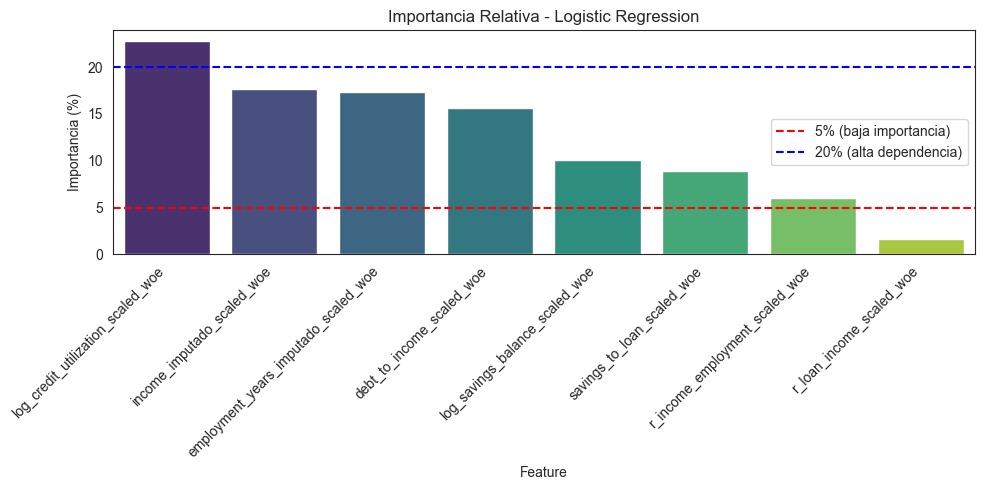

0.5204643398533441

📊 Metrics on Train Set (Logistic Regression, Threshold = 0.5205):
Recall: 0.7209
Precision: 0.402
F1 Score: 0.5161
ROC AUC: 0.8043
Average Precision (PR AUC): 0.5055
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82      4825
           1       0.40      0.72      0.52      1175

    accuracy                           0.74      6000
   macro avg       0.66      0.73      0.67      6000
weighted avg       0.82      0.74      0.76      6000



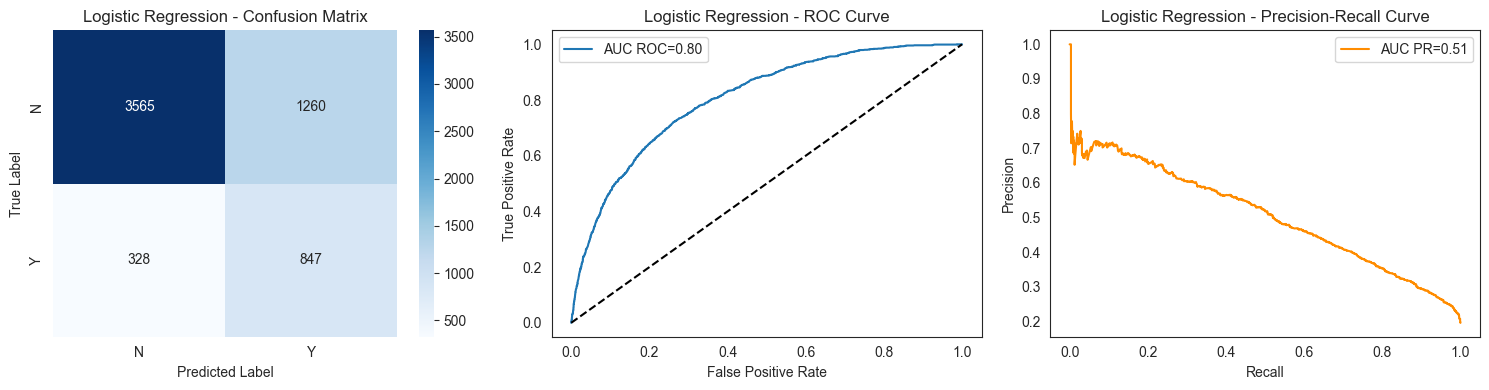

np.float64(0.4153565832711541)

In [13]:
#~~~~ Ajuste del modelo base: Logit ----

# Se penaliza un error en la clase minoritaria (malos) para mejorar su detección
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

param_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear', 'saga']
}

# Se optimiza por recall para maximizar la detección de clientes malos
search_lr = run_random_search(
    lr, param_lr, train[vars_modelo_woe], train['default'],
    cv, n_iter=10, scale=False, scoring='recall'
)

print("Best Hyperparameters Found:")
print(search_lr.best_params_)
print(f"Best Recall in CV: {search_lr.best_score_:.4f}")

best_lr = search_lr.best_estimator_
best_lr

#~~~~ Importancia Variables: Logit ----

log_reg = best_lr.named_steps['model']

importances = np.abs(log_reg.coef_[0])

features = vars_modelo_woe

rel_importance = 100* importances / importances.sum()

df_imp = pd.DataFrame({
    'feature': features,
    'importance': importances,
    'rel_importance': rel_importance
}).sort_values('rel_importance', ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_imp,
    x='feature',
    y='rel_importance',
    palette='viridis'
)

plt.axhline(5, color='red', linestyle='--', linewidth=1.5, label='5% (baja importancia)')
plt.axhline(20, color='blue', linestyle='--', linewidth=1.5, label='20% (alta dependencia)')

plt.title("Importancia Relativa - Logistic Regression")
plt.xlabel("Feature")
plt.ylabel("Importancia (%)")

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

y_proba_lr, y_pred_lr = evaluate_model(best_lr, train[vars_modelo_woe], train['default'], name='Logistic Regression')
plot_evaluation(train['default'], y_pred_lr, y_proba_lr, model_name='Logistic Regression')

#~~~~ Predicciones ----

y_proba = best_lr.predict_proba(train[vars_modelo_woe])[:, 1]
train['default_probability']= y_proba

train.default.mean()
train.default_probability.mean()


In [14]:
#____________________ Predicciones ----

# La imputación en test ya fue realizada previamente, con base en los valores calculados en train.

#~~~~ Creacion de Variables ----

test = test.assign(
    r_loan_income = test['loan_amount'] / test['income_imputado'].replace(0, np.nan),
    r_income_age = test['income_imputado'] / test['age'].replace(0, np.nan),
    r_savings_age = test['savings_balance'] / test['age'].replace(0, np.nan),
    r_income_employment = test['income_imputado'] / test['employment_years_imputado'].replace(0, np.nan)
)

test['flag_sin_consulta']=(test['num_credit_inquiries']>0).astype(int)
test['log_income']=np.where(test['income_imputado']==0,0, np.log(test['income_imputado']))
test['log_loan_amount']=np.where(test['loan_amount']==0,0, np.log(test['loan_amount']))
test['log_savings_balance']=np.where(test['savings_balance']==0,0, np.log(test['savings_balance']))
test['log_credit_utilization']=np.where(test['credit_utilization']==0,0, np.log(test['credit_utilization']))
test['log_savings_to_loan']=np.where(test['savings_to_loan']==0,0, np.log(test['savings_to_loan']))

test[vars_modelo_feature_scaled] = scaler_modelo_feature.transform(test[vars_modelo_feature])

#~~~~ WoE ----

test=pd.concat([test,sc.woebin_ply(test[good_vars + ['log_credit_utilization_scaled','credit_utilization_scaled']], bins)], axis=1)

#~~~~ Predicciones ----

y_proba = best_lr.predict_proba(test[vars_modelo_woe])[:, 1]
test['default_probability']= y_proba

test[['customer_id', 'default_probability']].to_csv(dir_r+r'/predicciones_rene_sangacha.csv', index=False)


[INFO] converting into woe values ...
